<div style="background-color: #F4F6F7; padding: 20px; border-radius: 8px; font-family: 'Arial', sans-serif; color: #2E4053;">
  <!-- Logo centrado -->
  <div style="text-align: center; margin-bottom: 15px;">
    <img src="https://drive.google.com/uc?export=view&id=1kjzXfjTiieYAd4azw5bh4UfEg91gUIdh" alt="Logo Institucional" width="250" />
  </div>

  <!-- Título principal -->
  <h1 style="font-size: 36px; font-weight: bold; text-align: right;">
    <strong>Estimación del gradiente geotérmico a partir de base de datos tabular mediante varios modelos de machine learning</strong>
  </h1>

  <!-- Datos del estudiante -->
  <p style="font-size: 22px; text-align: center; margin: 5px 0;">
    <strong>Nombre:</strong> Juan Fernando Castaño Sánchez &nbsp;|&nbsp;
    <strong>Institución:</strong> Universidad Tecnológica de Pereira  &nbsp;|&nbsp;
    <strong>Grupo de investigación en Automática </strong>
  </p>

  <hr style="border: 1px solid #ABB2B9; margin: 10px 0;" />

  <!-- Descripción breve -->
  <p style="font-size: 18px; text-align: center; font-style: italic; margin: 5px 0;">
    En este cuaderno se realizó la implemenración y prueba de diferentes modelos de machine learning para la predicción del gradiente geotérmico a partir de datos tabulares.

  </p>

  <hr style="border: 1px solid #ABB2B9; margin: 10px 0;" />
</div>

In [14]:
!pip install catboost

In [15]:
!pip install optuna

In [16]:
#Importacion de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import optuna
import xgboost as xgb
from tqdm import tqdm
from pathlib import Path
import seaborn as sns
# Modelos
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from catboost import CatBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import ParameterGrid, cross_val_score
from cuml.ensemble import RandomForestRegressor as CUMLRandomForestRegressor # Import cuML RandomForest

# Métricas y utilidades
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [17]:
#!gdown 1gNupu09mzDMq_GLrCJg2Au9UVUMsMCIQ #Base de datos cruda con pesos
!gdown 1OIJY8QtxRYr4HW504Awxama22OAuBJID

Downloading...
From: https://drive.google.com/uc?id=1OIJY8QtxRYr4HW504Awxama22OAuBJID
To: /kaggle/working/data_prep.csv
100%|███████████████████████████████████████| 1.01M/1.01M [00:00<00:00, 128MB/s]


In [18]:
# ==========================================
# 1. CONFIGURACIÓN Y CARGA
# ==========================================
# Asegúrate de que esta ruta sea correcta en tu entorno
#CSV_BASE = Path("/content/data_prep_w.csv")
#CSV_BASE = Path("/content/data_prep.csv")
CSV_BASE = Path("/kaggle/working/data_prep.csv")
TARGET_COL = "Apparent Geothermal Gradient (°C/Km)"
OUT_DIR = Path("/kaggle/working/run_comparison")
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [19]:
df_base = pd.read_csv(CSV_BASE, delimiter = ";")
display(df_base.head())

,Latitude,Longitude,Elevation (m),Surface Temperature (°C),Apparent Geothermal Gradient (°C/Km),Moho Depth (m),Magnetic Anomaly (nT),Fault,Strike-slip Fault,Reverse or Thrust Fault,...,Curie Depth (Km),Vertical Gravity Gradient (E),Free Air Anomaly (mGal),Bouguer Anomaly (mGal),Nearest Basement,Nearest Volcano,Volcanic domain,Volcanic weight,ID,Unnamed: 23
0,4.213002,-74.893581,313.9440,26.630280,14.712281,42863.91201,-43.6825,16042.94307,38240.01558,7608.200346,...,28,-54.87500,-107.350006,-155.604003,26430.35964,37574.49384,True,1,1,NaN
1,4.216078,-74.888898,313.3344,26.633328,21.294394,42855.31133,-43.6825,15471.82439,37942.35231,8075.823613,...,28,-54.87500,-107.350006,-155.604003,26807.50517,37828.18464,True,1,2,NaN
2,4.214720,-74.891220,316.3824,26.618088,23.783404,42859.26549,-43.6825,15751.33062,38097.70422,7838.753798,...,28,-54.87500,-107.350006,-155.604003,26613.39342,37691.34271,True,1,3,NaN
3,0.606276,-76.564731,275.2344,26.823828,24.156323,36310.81077,-3.9287,35178.98781,61605.45679,39427.671690,...,20,-0.40625,-26.175018,-58.520164,43126.50631,74754.72808,False,4,4,NaN
4,0.305911,-76.914853,90.5256,27.747372,25.601245,37832.87962,-2.2424,36371.53398,52965.25327,34306.255130,...,20,-3.53125,-27.399994,-55.094943,43893.01816,84568.77711,False,4,5,NaN


In [20]:
# Eliminar la última columna si su nombre contiene 'Unnamed'
if df_base.columns[-1].startswith('Unnamed'):
    print(f"Eliminando la última columna: {df_base.columns[-1]}")
    df_base = df_base.iloc[:, :-1]

display(df_base.head())

Eliminando la última columna: Unnamed: 23


,Latitude,Longitude,Elevation (m),Surface Temperature (°C),Apparent Geothermal Gradient (°C/Km),Moho Depth (m),Magnetic Anomaly (nT),Fault,Strike-slip Fault,Reverse or Thrust Fault,...,Active Fault,Curie Depth (Km),Vertical Gravity Gradient (E),Free Air Anomaly (mGal),Bouguer Anomaly (mGal),Nearest Basement,Nearest Volcano,Volcanic domain,Volcanic weight,ID
0,4.213002,-74.893581,313.9440,26.630280,14.712281,42863.91201,-43.6825,16042.94307,38240.01558,7608.200346,...,12107.51887,28,-54.87500,-107.350006,-155.604003,26430.35964,37574.49384,True,1,1
1,4.216078,-74.888898,313.3344,26.633328,21.294394,42855.31133,-43.6825,15471.82439,37942.35231,8075.823613,...,12521.08152,28,-54.87500,-107.350006,-155.604003,26807.50517,37828.18464,True,1,2
2,4.214720,-74.891220,316.3824,26.618088,23.783404,42859.26549,-43.6825,15751.33062,38097.70422,7838.753798,...,12309.04873,28,-54.87500,-107.350006,-155.604003,26613.39342,37691.34271,True,1,3
3,0.606276,-76.564731,275.2344,26.823828,24.156323,36310.81077,-3.9287,35178.98781,61605.45679,39427.671690,...,38740.87859,20,-0.40625,-26.175018,-58.520164,43126.50631,74754.72808,False,4,4
4,0.305911,-76.914853,90.5256,27.747372,25.601245,37832.87962,-2.2424,36371.53398,52965.25327,34306.255130,...,36506.15976,20,-3.53125,-27.399994,-55.094943,43893.01816,84568.77711,False,4,5


In [21]:
# Definir columnas predictoras (excluyendo ID y Target)
exclude_cols = ['ID','Latitude', 'Longitude', TARGET_COL]
# Buscar columnas en el dataframe que coincidan con nombres de coordenadas (ignorando mayúsculas/minúsculas)
tabular_cols = [c for c in df_base.columns if c not in exclude_cols]

# Convertir booleanos a enteros si existen
for col in tabular_cols:
    if df_base[col].dtype == 'bool':
        df_base[col] = df_base[col].astype(int)
print("Tabular columns used (sin lat/lon):", tabular_cols)

Tabular columns used (sin lat/lon): ['Elevation (m)', 'Surface Temperature (°C)', 'Moho Depth (m)', 'Magnetic Anomaly (nT)', 'Fault', 'Strike-slip Fault', 'Reverse or Thrust Fault', 'Lineament', 'Right-lateral Fault', 'Normal Fault', 'Active Fault', 'Curie Depth (Km)', 'Vertical Gravity Gradient (E)', 'Free Air Anomaly (mGal)', 'Bouguer Anomaly (mGal)', 'Nearest Basement', 'Nearest Volcano', 'Volcanic domain', 'Volcanic weight']


In [22]:
# ==========================================
# 2. PREPROCESAMIENTO
# ==========================================

# A. División Train/Test
train_df, test_df = train_test_split(df_base, test_size=0.2, random_state=42)

# B. Imputación (KNN)
imputer = KNNImputer(n_neighbors=8)
train_df[tabular_cols] = imputer.fit_transform(train_df[tabular_cols])
test_df[tabular_cols] = imputer.transform(test_df[tabular_cols])

# C. Escalado de Features (StandardScaler)
scaler = StandardScaler()
train_df[tabular_cols] = scaler.fit_transform(train_df[tabular_cols])
test_df[tabular_cols] = scaler.transform(test_df[tabular_cols])

# D. Transformación del Target (Log1p + Z-score)

min_target = train_df[TARGET_COL].min()
target_shift = 0.0
if min_target <= 0:
    target_shift = abs(min_target) + 1.0

# Aplicar Log
y_train_log = np.log1p(train_df[TARGET_COL] + target_shift)
y_test_log = np.log1p(test_df[TARGET_COL] + target_shift)

# Aplicar Z-score al target logarítmico
target_scaler = StandardScaler()
y_train_scaled = target_scaler.fit_transform(y_train_log.values.reshape(-1, 1)).flatten()
y_test_scaled = target_scaler.transform(y_test_log.values.reshape(-1, 1)).flatten()

# Guardar transformadores para invertir después
joblib.dump(target_scaler, OUT_DIR / "target_scaler.pkl")
joblib.dump({"shift": target_shift}, OUT_DIR / "target_shift.json")

# Definir X e y finales para entrenamiento
X_train = train_df[tabular_cols]
X_test = test_df[tabular_cols]
# Usamos el target escalado para entrenar
y_train_train = y_train_scaled

print(f"Datos listos. Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Datos listos. Train shape: (3634, 19), Test shape: (909, 19)


## Desnormalización y Cálculo de Métricas

In [23]:
# 1. Cargar transformadores (scaler y shift)
target_scaler = joblib.load(OUT_DIR / "target_scaler.pkl")
target_shift_data = joblib.load(OUT_DIR / "target_shift.json")
target_shift = target_shift_data["shift"]

print("Transformadores del target cargados exitosamente.")

Transformadores del target cargados exitosamente.


In [24]:
# 2. Función para desnormalizar el target
def inverse_target_transform(scaled_values, scaler, shift):
    # Inverse Z-score
    log_values = scaler.inverse_transform(np.array(scaled_values).reshape(-1, 1)).flatten()
    # Inverse log1p
    original_values = np.expm1(log_values) - shift
    return original_values

print("Función inverse_target_transform definida.")

Función inverse_target_transform definida.


# **CatBoost**

In [25]:
def objective_cb(trial):
  param_grid = {
    "depth": trial.suggest_int("depth", 6, 10), # CatBoost is heavy; 10+ is very slow
    "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
    "iterations": trial.suggest_int("iterations", 200, 500),
    "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 10),
    "l2_leaf_reg": trial.suggest_int("l2_leaf_reg", 1, 10),
    #"subsample": [0.6, 0.8, 1.0],
    #"rsm": [0.6, 0.8, 1.0], # This is the equivalent of colsample_bytree
    #"bootstrap_type": ['Bernoulli'] # Added to support 'subsample'
  }
  model_cb = CatBoostRegressor(verbose = 0,
                               task_type = "GPU",
                             **param_grid
  )

  score = cross_val_score(model_cb, X_train, y_train_train, cv=5, scoring='neg_mean_squared_error')
  return score.mean()





In [26]:
study_cb = optuna.create_study(direction='maximize', sampler = optuna.samplers.RandomSampler(seed=42))


[I 2026-03-20 02:40:37,550] A new study created in memory with name: no-name-0fe3c884-a611-4a78-9618-ee9179e0829a


In [27]:
study_cb.optimize(objective_cb, n_trials=100)

[I 2026-03-20 02:40:54,867] Trial 0 finished with value: -0.5385503464082726 and parameters: {'depth': 7, 'learning_rate': 0.08927180304353628, 'iterations': 420, 'min_data_in_leaf': 6, 'l2_leaf_reg': 2}. Best is trial 0 with value: -0.5385503464082726.
[I 2026-03-20 02:41:10,483] Trial 1 finished with value: -0.5518417259357898 and parameters: {'depth': 6, 'learning_rate': 0.011430983876313222, 'iterations': 460, 'min_data_in_leaf': 7, 'l2_leaf_reg': 8}. Best is trial 0 with value: -0.5385503464082726.
[I 2026-03-20 02:41:25,968] Trial 2 finished with value: -0.537507985097139 and parameters: {'depth': 6, 'learning_rate': 0.09330606024425668, 'iterations': 450, 'min_data_in_leaf': 3, 'l2_leaf_reg': 2}. Best is trial 2 with value: -0.537507985097139.
[I 2026-03-20 02:41:37,985] Trial 3 finished with value: -0.5414204342857125 and parameters: {'depth': 6, 'learning_rate': 0.02014847788415866, 'iterations': 357, 'min_data_in_leaf': 5, 'l2_leaf_reg': 3}. Best is trial 2 with value: -0.537

In [28]:
study_cb.best_params

{'depth': 8,
 'learning_rate': 0.0491920812880881,
 'iterations': 396,
 'min_data_in_leaf': 3,
 'l2_leaf_reg': 8}

In [29]:
best_params_cb = study_cb.best_params

In [30]:
best_catb_model = CatBoostRegressor(**best_params_cb)
best_catb_model.fit(X_train, y_train_train)

0:	learn: 0.9827294	total: 27.8ms	remaining: 11s
1:	learn: 0.9667158	total: 38.7ms	remaining: 7.63s
2:	learn: 0.9512765	total: 56.7ms	remaining: 7.42s
3:	learn: 0.9363869	total: 66.9ms	remaining: 6.55s
4:	learn: 0.9223622	total: 77ms	remaining: 6.02s
5:	learn: 0.9107210	total: 85.6ms	remaining: 5.57s
6:	learn: 0.9003516	total: 94.3ms	remaining: 5.24s
7:	learn: 0.8891638	total: 103ms	remaining: 4.99s
8:	learn: 0.8788653	total: 112ms	remaining: 4.79s
9:	learn: 0.8693200	total: 120ms	remaining: 4.62s
10:	learn: 0.8600473	total: 128ms	remaining: 4.49s
11:	learn: 0.8519682	total: 137ms	remaining: 4.39s
12:	learn: 0.8439771	total: 146ms	remaining: 4.29s
13:	learn: 0.8364786	total: 154ms	remaining: 4.21s
14:	learn: 0.8290928	total: 163ms	remaining: 4.13s
15:	learn: 0.8225977	total: 171ms	remaining: 4.06s
16:	learn: 0.8162409	total: 179ms	remaining: 4s
17:	learn: 0.8098949	total: 188ms	remaining: 3.94s
18:	learn: 0.8039585	total: 196ms	remaining: 3.9s
19:	learn: 0.7984200	total: 205ms	remainin

In [31]:
joblib.dump(best_catb_model, OUT_DIR / "catboost_model.pkl")
print("Modelo entrenado y guardado.")

Modelo entrenado y guardado.


In [32]:
best_catb_model = joblib.load(OUT_DIR / 'catboost_model.pkl')

In [33]:
y_train_pred = best_catb_model.predict(X_train)

# Metrics for the training set
mae_train_catb = mean_absolute_error(y_train_train, y_train_pred)
r2_train_catb = r2_score(y_train_train, y_train_pred)

print("Training Set Metrics:")
print(f"MAE: {mae_train_catb}")
print(f"R-squared: {r2_train_catb}")

Training Set Metrics:
MAE: 0.41929009807254086
R-squared: 0.6331281181477172


In [34]:
# Predictions on the test set
y_test_pred = best_catb_model.predict(X_test)

# Metrics for the test set
mae_test_catb = mean_absolute_error(y_test_scaled, y_test_pred)
mse_test_catb = mean_squared_error(y_test_scaled, y_test_pred)
rmse_test_catb = np.sqrt(mse_test_catb)
r2_test_catb = r2_score(y_test_scaled, y_test_pred)

print("\nTest Set Metrics:")
print(f"MAE: {mae_test_catb}")
print(f"MSE: {mse_test_catb}")
print(f"RMSE (CatBoost): {rmse_test_catb}")
print(f"R-squared: {r2_test_catb}")


Test Set Metrics:
MAE: 0.49881900820036285
MSE: 0.6023895730890434
RMSE (CatBoost): 0.7761375993269772
R-squared: 0.44306683834988425


In [35]:
# --- Métricas Desnormalizadas para CatBoostRegressor ---

# Desnormalizar valores reales del target (training set)
y_train_original_scale = inverse_target_transform(y_train_scaled, target_scaler, target_shift)
# Desnormalizar predicciones  (training set)
y_catb_train_pred_original_scale = inverse_target_transform(y_train_pred, target_scaler, target_shift)

# Calcular métricas desnormalizadas para (training set)
mae_catb_train_denormalized = mean_absolute_error(y_train_original_scale, y_catb_train_pred_original_scale)
r2_catb_train_denormalized = r2_score(y_train_original_scale, y_catb_train_pred_original_scale)
rmse_catb_train_denormalized = np.sqrt(np.mean((y_train_original_scale - y_catb_train_pred_original_scale)**2))
print("\nCatBoostRegressor Denormalized Metrics (Training Set):")
print(f"MAE: {mae_catb_train_denormalized:.4f}")
print(f"RMSE: {rmse_catb_train_denormalized:.4f}")
print(f"R-squared: {r2_catb_train_denormalized:.4f}")


CatBoostRegressor Denormalized Metrics (Training Set):
MAE: 2.3670
RMSE: 3.7685
R-squared: 0.6032


In [36]:
# Desnormalizar valores reales del target (test set)
y_test_original_scale = inverse_target_transform(y_test_scaled, target_scaler, target_shift)
# Desnormalizar predicciones  (test set)
y_catb_test_pred_original_scale = inverse_target_transform(y_test_pred, target_scaler, target_shift)

# Calcular métricas desnormalizadas para  (test set)
mae_catb_denormalized = mean_absolute_error(y_test_original_scale, y_catb_test_pred_original_scale)
r2_catb_denormalized = r2_score(y_test_original_scale, y_catb_test_pred_original_scale)
rmse_catb_denormalized = np.sqrt(np.mean((y_test_original_scale - y_catb_test_pred_original_scale)**2))
print("\nCatBoostRegressor Denormalized Metrics (Test Set):")
print(f"MAE: {mae_catb_denormalized:.4f}")
print(f"RMSE: {rmse_catb_denormalized:.4f}")
print(f"R-squared: {r2_catb_denormalized:.4f}")


CatBoostRegressor Denormalized Metrics (Test Set):
MAE: 2.8194
RMSE: 4.8312
R-squared: 0.4018


# **XGBOOST**

In [37]:
# Convertir datos a DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train_train)
dtest = xgb.DMatrix(X_test, label=y_test_scaled)

def objective_xgb(trial):
  params = {
      'objective': 'reg:squarederror',
      'eval_metric': 'rmse',
      'tree_method': 'hist',
      'device': 'cuda',
      'max_depth': trial.suggest_int('max_depth', 3, 15),
      'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
      'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
      'gamma': trial.suggest_float('gamma', 0.0, 0.5),
      'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
      'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
      'subsample': trial.suggest_float('subsample', 0.5, 1.0),
      'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
      'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 2.0),
      'random_state': 42
  }

  model_xgb = XGBRegressor(**params)

  score = cross_val_score(model_xgb, X_train, y_train_train, cv=5, scoring='neg_mean_squared_error')
  return score.mean()

In [38]:
study_xgb = optuna.create_study(direction='maximize', sampler = optuna.samplers.RandomSampler(seed=42))


[I 2026-03-20 03:08:12,404] A new study created in memory with name: no-name-497aa5dd-df39-4f61-8764-db536b613e8c


In [39]:
study_xgb.optimize(objective_xgb, n_trials=100)

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:774: UserWarning: [03:08:13] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
[I 2026-03-20 03:08:17,381] Trial 0 finished with value: -0.6107424913432516 and parameters: {'max_depth': 7, 'learning_rate': 0.1667521176194013, 'n_estimators': 759, 'gamma': 0.2993292420985183, 'min_child_weight': 2, 'colsample_bytree': 0.5779972601681014, 'subsample': 0.5290418060840998, 'reg_alpha': 0.8661761457749352, 'reg_lambda': 1.4016725176148133}. Best is trial 0 with value: -0.6107424913432516.
[I 2026-03-20 03:08:33,308] Trial 1 finished 

In [40]:
study_xgb.best_params

{'max_depth': 9,
 'learning_rate': 0.006182762880853937,
 'n_estimators': 595,
 'gamma': 0.2207652506866885,
 'min_child_weight': 9,
 'colsample_bytree': 0.6754575062760393,
 'subsample': 0.558533508213803,
 'reg_alpha': 0.14299168205283586,
 'reg_lambda': 1.6422659475762083}

In [41]:
best_params_xgb = study_xgb.best_params

In [42]:
#Entrenar
best_xgb_model = XGBRegressor(**best_params_xgb)
best_xgb_model.fit(X_train, y_train_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6754575062760393, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=0.2207652506866885, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.006182762880853937,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=9, max_leaves=None,
             min_child_weight=9, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=595, n_jobs=None,
             num_parallel_tree=None, ...)

In [43]:
# Guardar modelo XGBOOST
joblib.dump(best_xgb_model, OUT_DIR / "xgboost_model.pkl")
print("Modelo entrenado y guardado.")

Modelo entrenado y guardado.


In [44]:
# Cargar modelo
best_xgb_model = joblib.load(OUT_DIR / 'xgboost_model.pkl')

In [45]:
# Predictions on the training set
y_xgb_train_pred = best_xgb_model.predict(X_train)

# Metrics for the training set
mae_train_xgb = mean_absolute_error(y_train_train, y_xgb_train_pred)
mse_train_xgb = mean_squared_error(y_train_train, y_xgb_train_pred)
rmse_train_xgb = np.sqrt(mse_train_xgb)
r2_train_xgb = r2_score(y_train_train, y_xgb_train_pred)

print("Training Set Metrics:")
print(f"MAE: {mae_train_xgb}")
print(f"RMSE: {rmse_train_xgb}")
print(f"R-squared: {r2_train_xgb}")

Training Set Metrics:
MAE: 0.3809923217558732
RMSE: 0.5629480084820813
R-squared: 0.6830895397460586


In [46]:
# Predictions on the test set
y_xgb_test_pred = best_xgb_model.predict(X_test)

# Metrics for the test set
mae_test_xgb = mean_absolute_error(y_test_scaled, y_xgb_test_pred)
mse_test_xgb = mean_squared_error(y_test_scaled, y_xgb_test_pred)
rmse_test_xgb = np.sqrt(mse_test_xgb)
r2_test_xgb = r2_score(y_test_scaled, y_xgb_test_pred)

print("\nTest Set Metrics:")
print(f"MAE: {mae_test_xgb}")
print(f"MSE: {mse_test_xgb}")
print(f"RMSE: {rmse_test_xgb}")
print(f"R-squared: {r2_test_xgb}")


Test Set Metrics:
MAE: 0.49717941513697683
MSE: 0.6126701450986046
RMSE: 0.782732486293117
R-squared: 0.4335620399127269


In [47]:
# --- Métricas Desnormalizadas para XGBoostRegressor ---

# Desnormalizar valores reales del target (training set)
y_train_original_scale = inverse_target_transform(y_train_scaled, target_scaler, target_shift)
# Desnormalizar predicciones  (training set)
y_xgb_train_pred_original_scale = inverse_target_transform(y_xgb_train_pred, target_scaler, target_shift)

# Calcular métricas desnormalizadas para (training set)
mae_xgb_train_denormalized = mean_absolute_error(y_train_original_scale, y_xgb_train_pred_original_scale)
r2_xgb_train_denormalized = r2_score(y_train_original_scale, y_xgb_train_pred_original_scale)
rmse_xgb_train_denormalized = np.sqrt(np.mean((y_train_original_scale - y_xgb_train_pred_original_scale)**2))
print("\nXGBRegressor Denormalized Metrics (Training Set):")
print(f"MAE: {mae_xgb_train_denormalized:.4f}")
print(f"RMSE: {rmse_xgb_train_denormalized:.4f}")
print(f"R-squared: {r2_xgb_train_denormalized:.4f}")


XGBRegressor Denormalized Metrics (Training Set):
MAE: 2.1614
RMSE: 3.5472
R-squared: 0.6485


In [48]:
# Desnormalizar valores reales del target (test set)
y_test_original_scale = inverse_target_transform(y_test_scaled, target_scaler, target_shift)
# Desnormalizar predicciones  (test set)
y_xgb_test_pred_original_scale = inverse_target_transform(y_xgb_test_pred, target_scaler, target_shift)

# Calcular métricas desnormalizadas para  (test set)
mae_xgb_denormalized = mean_absolute_error(y_test_original_scale, y_xgb_test_pred_original_scale)
r2_xgb_denormalized = r2_score(y_test_original_scale, y_xgb_test_pred_original_scale)
rmse_xgb_denormalized = np.sqrt(np.mean((y_test_original_scale - y_xgb_test_pred_original_scale)**2))
print("\nXGBRegressor Denormalized Metrics (Test Set):")
print(f"MAE: {mae_xgb_denormalized:.4f}")
print(f"RMSE: {rmse_xgb_denormalized:.4f}")
print(f"R-squared: {r2_xgb_denormalized:.4f}")


XGBRegressor Denormalized Metrics (Test Set):
MAE: 2.8092
RMSE: 4.8679
R-squared: 0.3927


# **LIGHTGBM**

In [49]:
def objective_lgb(trial):
  params = {
      "objective": "regression",
      "metric": "rmse",
      "verbose": -1,
      "boosting_type": "gbdt",
      "n_jobs": -1, # Use all available cores
      "random_state": 42,
      # Hyperparameters to tune
      "num_leaves": trial.suggest_categorical("num_leaves", [31, 63, 127]),
      "max_depth": trial.suggest_categorical("max_depth", [-1, 10, 15]),
      "learning_rate": trial.suggest_categorical("learning_rate", [0.01, 0.05, 0.1]),
      "n_estimators": trial.suggest_categorical("n_estimators", [500, 1000]),
      "subsample": trial.suggest_categorical("subsample", [0.8]),
      "bagging_freq": trial.suggest_categorical("bagging_freq", [5]),
      "colsample_bytree": trial.suggest_categorical("colsample_bytree", [0.8, 1.0]),
      "reg_alpha": trial.suggest_categorical("reg_alpha", [0.0, 0.1]),
      "reg_lambda": trial.suggest_categorical("reg_lambda", [0.0, 0.1]),
      # GPU Specifics
      "device": "gpu",
      "max_bin": 63,
      "gpu_use_dp": False
  }

  model_lgb = LGBMRegressor(**params)

  score = cross_val_score(model_lgb, X_train, y_train_train, cv=5, scoring='neg_mean_squared_error')
  return score.mean()

In [50]:
study_lgb = optuna.create_study(direction='maximize', sampler = optuna.samplers.RandomSampler(seed=42))

[I 2026-03-20 03:16:07,432] A new study created in memory with name: no-name-668923d4-d912-4da7-b821-2f8c58f8b58e


In [51]:
study_lgb.optimize(objective_lgb, n_trials=100)

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
[I 2026-03-20 03:16:26,986] Trial 0 finished with value: -0.6137105306952574 and parameters: {'num_leaves': 63, 'max_depth': -1, 'learning_rate': 0.05, 'n_estimators': 500, 'subsample': 0.8, 'bagging_freq': 5, 'colsample_bytree': 0.8, 'reg_alpha': 0.0, 'reg_lambda': 0.1}. Best is trial 0 with value: -0.613

In [52]:
study_lgb.best_params

{'num_leaves': 31,
 'max_depth': 15,
 'learning_rate': 0.01,
 'n_estimators': 500,
 'subsample': 0.8,
 'bagging_freq': 5,
 'colsample_bytree': 0.8,
 'reg_alpha': 0.0,
 'reg_lambda': 0.0}

In [53]:
best_params_lgb = study_lgb.best_params

In [54]:
#Entrenar
best_lgb_model = LGBMRegressor(**best_params_lgb)
best_lgb_model.fit(X_train, y_train_train)

LGBMRegressor(bagging_freq=5, colsample_bytree=0.8, learning_rate=0.01,
              max_depth=15, n_estimators=500, subsample=0.8)

In [55]:
joblib.dump(best_lgb_model, OUT_DIR / "lightgbm_model.pkl")
print("Modelo entrenado y guardado.")

Modelo entrenado y guardado.


In [56]:
best_lgb_model = joblib.load(OUT_DIR / 'lightgbm_model.pkl')

In [57]:
# Predictions on the training set
y_lgb_train_pred = best_lgb_model.predict(X_train)

# Metrics for the training set
mae_train_lgb = mean_absolute_error(y_train_train, y_lgb_train_pred)
mse_train_lgb = mean_squared_error(y_train_train, y_lgb_train_pred)
rmse_train_lgb = np.sqrt(mse_train_lgb)
r2_train_lgb = r2_score(y_train_train, y_lgb_train_pred)

print("Training Set Metrics:")
print(f"MAE: {mae_train_lgb}")
print(f"RMSE: {rmse_train_lgb}")
print(f"R-squared: {r2_train_lgb}")

Training Set Metrics:
MAE: 0.40163260976696413
RMSE: 0.5890810137216146
R-squared: 0.6529835592727148


In [58]:
# Predictions on the test set
y_lgb_test_pred = best_lgb_model.predict(X_test)

# Metrics for the test set
mae_test_lgb = mean_absolute_error(y_test_scaled, y_lgb_test_pred)
mse_test_lgb = mean_squared_error(y_test_scaled, y_lgb_test_pred)
rmse_test_lgb = np.sqrt(mse_test_lgb)
r2_test_lgb = r2_score(y_test_scaled, y_lgb_test_pred)

print("\nTest Set Metrics:")
print(f"MAE: {mae_test_lgb}")
print(f"MSE: {mse_test_lgb}")
print(f"RMSE: {rmse_test_lgb}")
print(f"R-squared: {r2_test_lgb}")


Test Set Metrics:
MAE: 0.5002653861251446
MSE: 0.6171598780858463
RMSE: 0.7855952380748283
R-squared: 0.42941110287919415


In [59]:
# --- Métricas Desnormalizadas para LightGBM ---

# Desnormalizar valores reales del target (training set)
y_train_original_scale = inverse_target_transform(y_train_scaled, target_scaler, target_shift)
# Desnormalizar predicciones  (training set)
y_lgb_train_pred_original_scale = inverse_target_transform(y_lgb_train_pred, target_scaler, target_shift)

# Calcular métricas desnormalizadas para (training set)
mae_lgb_train_denormalized = mean_absolute_error(y_train_original_scale, y_lgb_train_pred_original_scale)
r2_lgb_train_denormalized = r2_score(y_train_original_scale, y_lgb_train_pred_original_scale)
rmse_lgb_train_denormalized = np.sqrt(np.mean((y_train_original_scale - y_lgb_train_pred_original_scale)**2))
print("\nLightGBM Denormalized Metrics (Training Set):")
print(f"MAE: {mae_lgb_train_denormalized:.4f}")
print(f"RMSE: {rmse_lgb_train_denormalized:.4f}")
print(f"R-squared: {r2_lgb_train_denormalized:.4f}")


LightGBM Denormalized Metrics (Training Set):
MAE: 2.2747
RMSE: 3.6814
R-squared: 0.6214


In [60]:
# Desnormalizar valores reales del target (test set)
y_test_original_scale = inverse_target_transform(y_test_scaled, target_scaler, target_shift)
# Desnormalizar predicciones  (test set)
y_lgb_test_pred_original_scale = inverse_target_transform(y_lgb_test_pred, target_scaler, target_shift)

# Calcular métricas desnormalizadas para  (test set)
mae_lgb_denormalized = mean_absolute_error(y_test_original_scale, y_lgb_test_pred_original_scale)
r2_lgb_denormalized = r2_score(y_test_original_scale, y_lgb_test_pred_original_scale)
rmse_lgb_denormalized = np.sqrt(np.mean((y_test_original_scale - y_lgb_test_pred_original_scale)**2))
print("\nLightGBM Denormalized Metrics (Test Set):")
print(f"MAE: {mae_lgb_denormalized:.4f}")
print(f"RMSE: {rmse_lgb_denormalized:.4f}")
print(f"R-squared: {r2_lgb_denormalized:.4f}")


LightGBM Denormalized Metrics (Test Set):
MAE: 2.8265
RMSE: 4.8844
R-squared: 0.3886


# **cuML RandomForest**

In [61]:
def objective_cuml_rf(trial):
  params = {
      "n_estimators": trial.suggest_int("n_estimators", 50, 500),
      "max_depth": trial.suggest_int("max_depth", 2, 32),
      "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.7, 0.9]),
      "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
      "random_state": 42
  }

  model_cuml_rf = CUMLRandomForestRegressor(**params)
  score = cross_val_score(model_cuml_rf, X_train, y_train_train, cv=5, scoring='neg_mean_squared_error')
  return score.mean()

In [62]:
study_cuml_rf = optuna.create_study(direction='maximize', sampler=optuna.samplers.RandomSampler(seed=42))

[I 2026-03-20 03:49:35,259] A new study created in memory with name: no-name-cc801066-4da0-4f6a-9056-de812f62bb01


In [63]:
study_cuml_rf.optimize(objective_cuml_rf, n_trials=100)

[I 2026-03-20 03:49:39,032] Trial 0 finished with value: -0.5317527489547488 and parameters: {'n_estimators': 218, 'max_depth': 31, 'max_features': 'sqrt', 'min_samples_leaf': 18}. Best is trial 0 with value: -0.5317527489547488.
[I 2026-03-20 03:49:44,118] Trial 1 finished with value: -0.5237409514176709 and parameters: {'n_estimators': 321, 'max_depth': 23, 'max_features': 'log2', 'min_samples_leaf': 4}. Best is trial 1 with value: -0.5237409514176709.
[I 2026-03-20 03:49:46,695] Trial 2 finished with value: -0.5222179985535114 and parameters: {'n_estimators': 187, 'max_depth': 18, 'max_features': 0.5, 'min_samples_leaf': 8}. Best is trial 2 with value: -0.5222179985535114.
[I 2026-03-20 03:49:51,430] Trial 3 finished with value: -0.5371413799526847 and parameters: {'n_estimators': 255, 'max_depth': 26, 'max_features': 0.9, 'min_samples_leaf': 4}. Best is trial 2 with value: -0.5222179985535114.
[I 2026-03-20 03:49:52,534] Trial 4 finished with value: -0.5218531329235429 and paramete

In [64]:
study_cuml_rf.best_params

{'n_estimators': 317,
 'max_depth': 13,
 'max_features': 'sqrt',
 'min_samples_leaf': 6}

In [65]:
best_params_cuml_rf = study_cuml_rf.best_params

In [66]:
# Train the best cuML RandomForest model
best_cuml_rf_model = CUMLRandomForestRegressor(**best_params_cuml_rf)
best_cuml_rf_model.fit(X_train, y_train_train)
print("cuML RandomForest model trained with best parameters.")

cuML RandomForest model trained with best parameters.


In [67]:
joblib.dump(best_cuml_rf_model, OUT_DIR / "cuml_rf_model.pkl")
print("cuML RandomForest model saved.")

cuML RandomForest model saved.


In [68]:
best_cuml_rf_model = joblib.load(OUT_DIR / 'cuml_rf_model.pkl')

In [69]:
# Predictions on the training set
y_cuml_rf_train_pred = best_cuml_rf_model.predict(X_train)

# Metrics for the training set
mae_train_cuml_rf = mean_absolute_error(y_train_train, y_cuml_rf_train_pred)
mse_train_cuml_rf = mean_squared_error(y_train_train, y_cuml_rf_train_pred)
rmse_train_cuml_rf = np.sqrt(mse_train_cuml_rf)
r2_train_cuml_rf = r2_score(y_train_train, y_cuml_rf_train_pred)

print("\ncuML RandomForest Training Set Metrics (Scaled Target):")
print(f"MAE: {mae_train_cuml_rf}")
print(f"RMSE: {rmse_train_cuml_rf}")
print(f"R-squared: {r2_train_cuml_rf}")


cuML RandomForest Training Set Metrics (Scaled Target):
MAE: 0.3819951615114338
RMSE: 0.5715988584279676
R-squared: 0.6732747450438441


In [70]:
# Predictions on the test set
y_cuml_rf_test_pred = best_cuml_rf_model.predict(X_test)

# Metrics for the test set
mae_test_cuml_rf = mean_absolute_error(y_test_scaled, y_cuml_rf_test_pred)
mse_test_cuml_rf = mean_squared_error(y_test_scaled, y_cuml_rf_test_pred)
rmse_test_cuml_rf = np.sqrt(mse_test_cuml_rf)
r2_test_cuml_rf = r2_score(y_test_scaled, y_cuml_rf_test_pred)

print("\ncuML RandomForest Test Set Metrics (Scaled Target):")
print(f"MAE: {mae_test_cuml_rf}")
print(f"MSE: {mse_test_cuml_rf}")
print(f"RMSE: {rmse_test_cuml_rf}")
print(f"R-squared: {r2_test_cuml_rf}")


cuML RandomForest Test Set Metrics (Scaled Target):
MAE: 0.497336427156753
MSE: 0.6139731456410981
RMSE: 0.7835643851280494
R-squared: 0.43235736399504565


# --- Métricas Desnormalizadas para cuML RandomForestRegressor ---

In [71]:
# Desnormalizar valores reales del target (training set)
y_train_original_scale = inverse_target_transform(y_train_scaled, target_scaler, target_shift)
# Desnormalizar predicciones  (training set)
y_cuml_rf_train_pred_original_scale = inverse_target_transform(y_cuml_rf_train_pred, target_scaler, target_shift)

# Calcular métricas desnormalizadas para (training set)
mae_cuml_rf_train_denormalized = mean_absolute_error(y_train_original_scale, y_cuml_rf_train_pred_original_scale)
r2_cuml_rf_train_denormalized = r2_score(y_train_original_scale, y_cuml_rf_train_pred_original_scale)
rmse_cuml_rf_train_denormalized = np.sqrt(np.mean((y_train_original_scale - y_cuml_rf_train_pred_original_scale)**2))
print("\ncuML RandomForest Denormalized Metrics (Training Set):")
print(f"MAE: {mae_cuml_rf_train_denormalized:.4f}")
print(f"RMSE: {rmse_cuml_rf_train_denormalized:.4f}")
print(f"R-squared: {r2_cuml_rf_train_denormalized:.4f}")


cuML RandomForest Denormalized Metrics (Training Set):
MAE: 2.1709
RMSE: 3.6177
R-squared: 0.6344


In [72]:
# Desnormalizar valores reales del target (test set)
y_test_original_scale = inverse_target_transform(y_test_scaled, target_scaler, target_shift)
# Desnormalizar predicciones  (test set)
y_cuml_rf_test_pred_original_scale = inverse_target_transform(y_cuml_rf_test_pred, target_scaler, target_shift)

# Calcular métricas desnormalizadas para  (test set)
mae_cuml_rf_denormalized = mean_absolute_error(y_test_original_scale, y_cuml_rf_test_pred_original_scale)
r2_cuml_rf_denormalized = r2_score(y_test_original_scale, y_cuml_rf_test_pred_original_scale)
rmse_cuml_rf_denormalized = np.sqrt(np.mean((y_test_original_scale - y_cuml_rf_test_pred_original_scale)**2))
print("\ncuML RandomForest Denormalized Metrics (Test Set):")
print(f"MAE: {mae_cuml_rf_denormalized:.4f}")
print(f"RMSE: {rmse_cuml_rf_denormalized:.4f}")
print(f"R-squared: {r2_cuml_rf_denormalized:.4f}")


cuML RandomForest Denormalized Metrics (Test Set):
MAE: 2.8126
RMSE: 4.8774
R-squared: 0.3904


# **Gráficas y resultados**

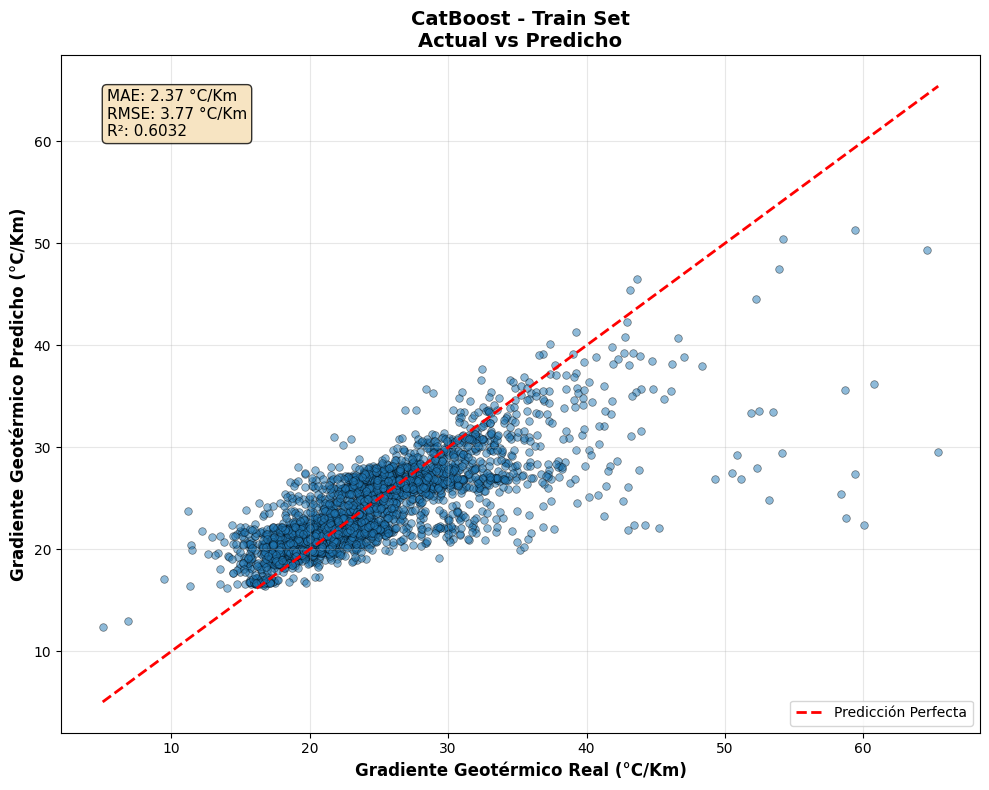

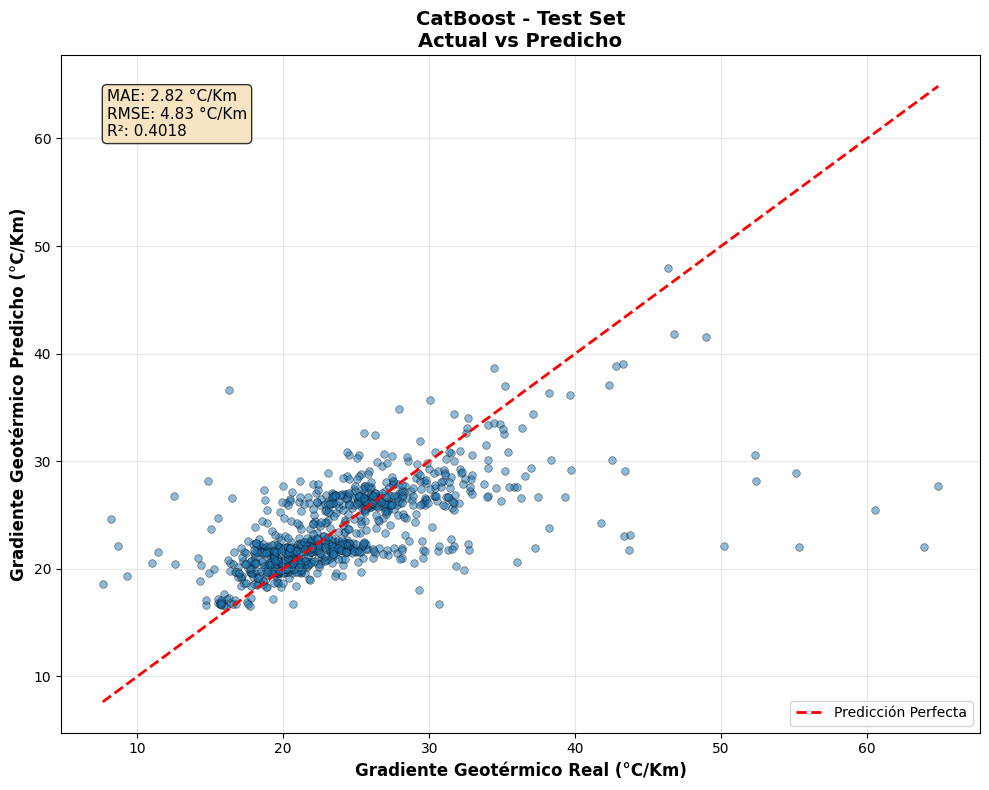

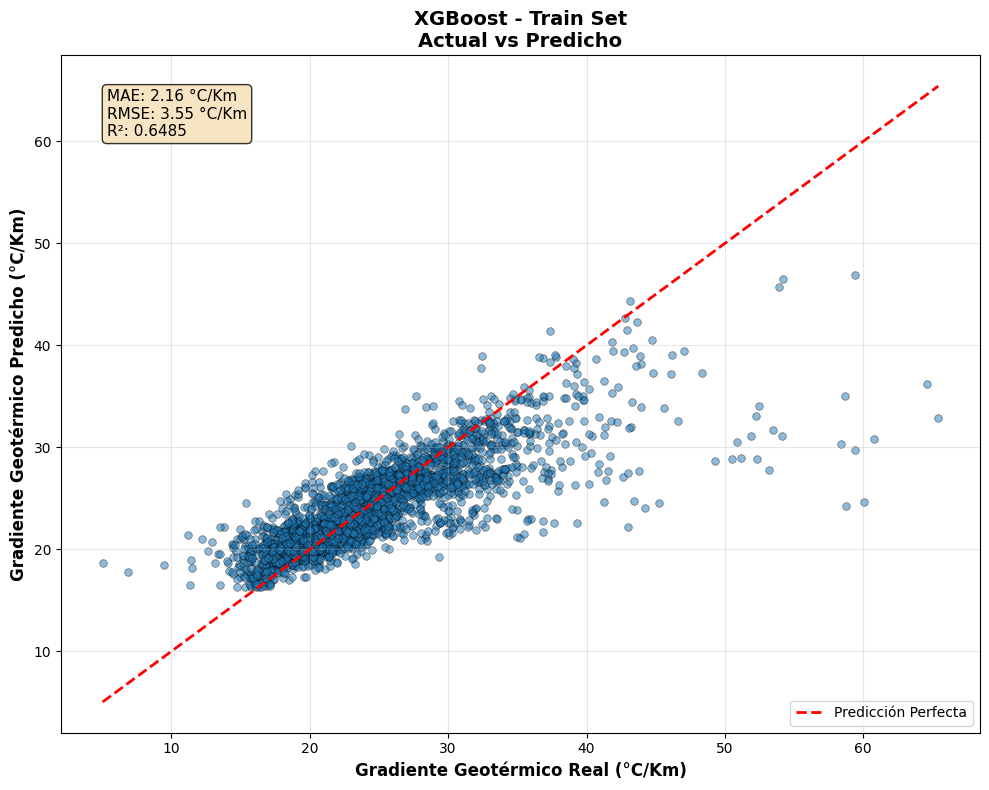

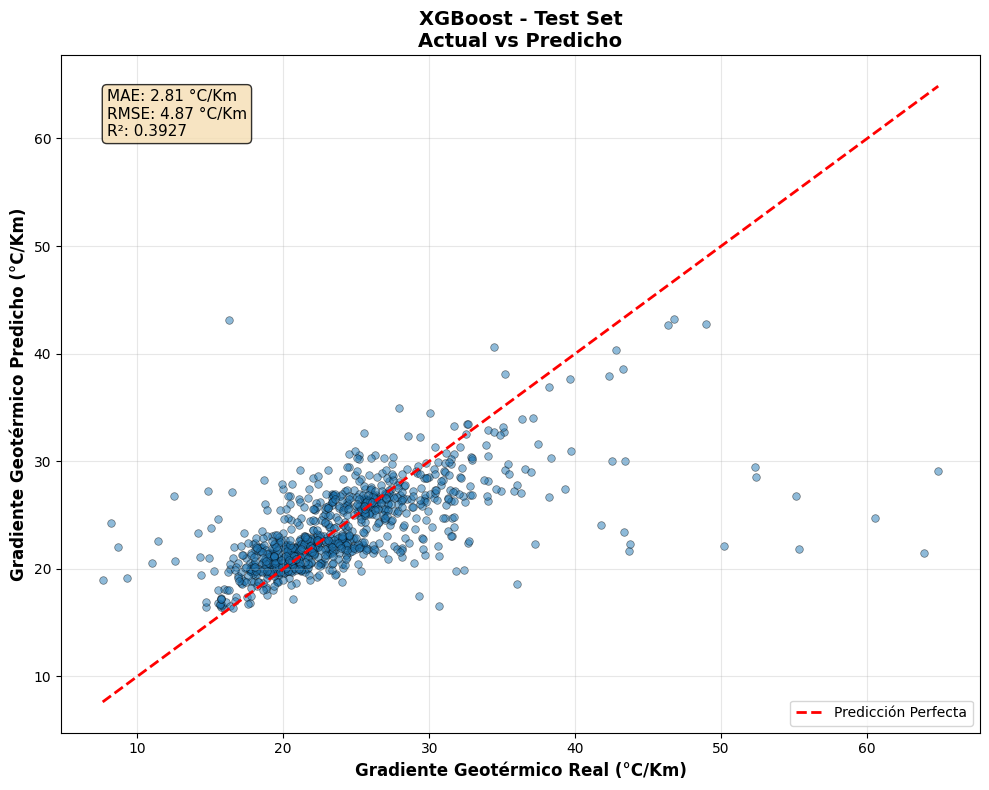

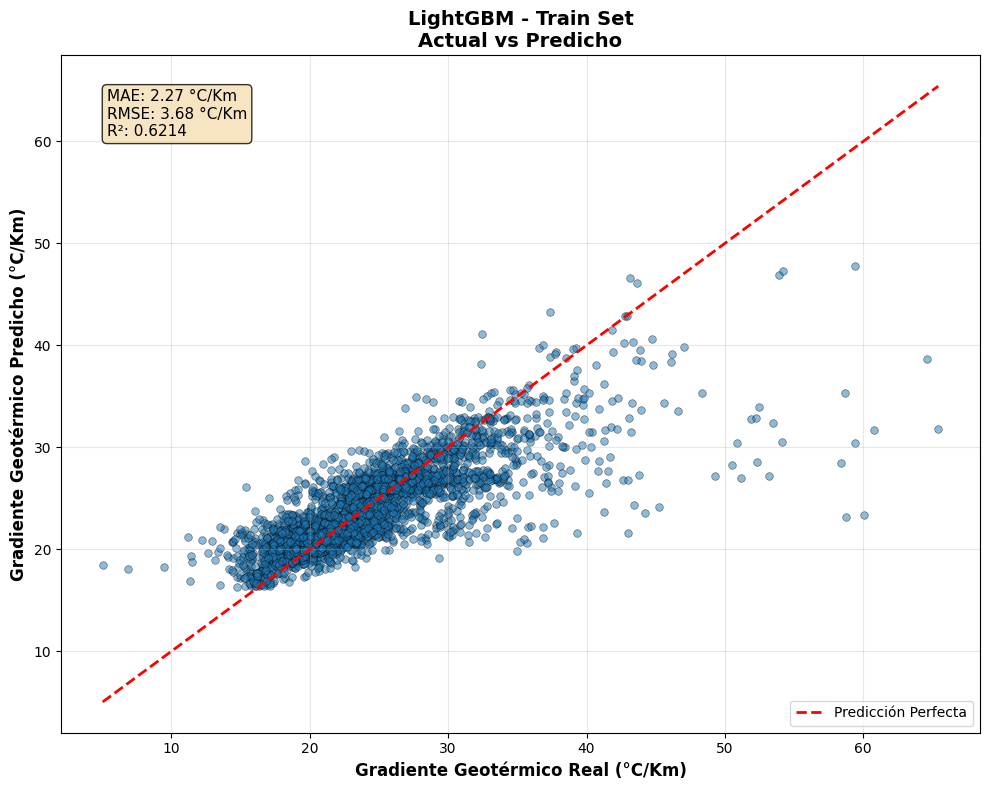

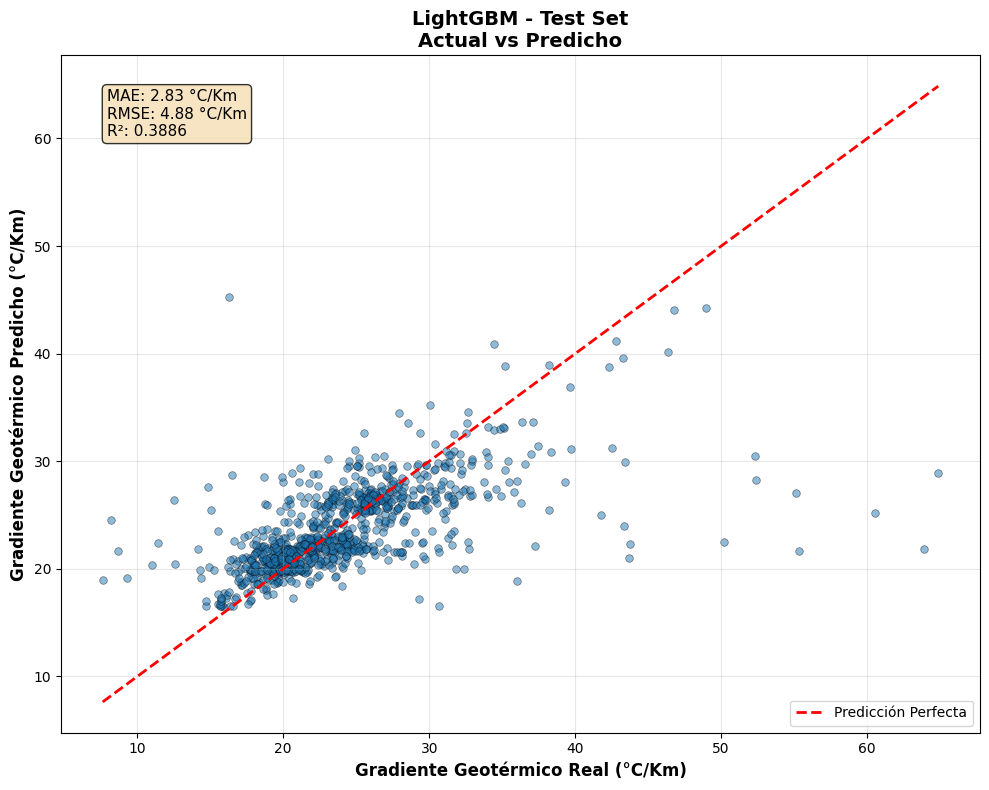

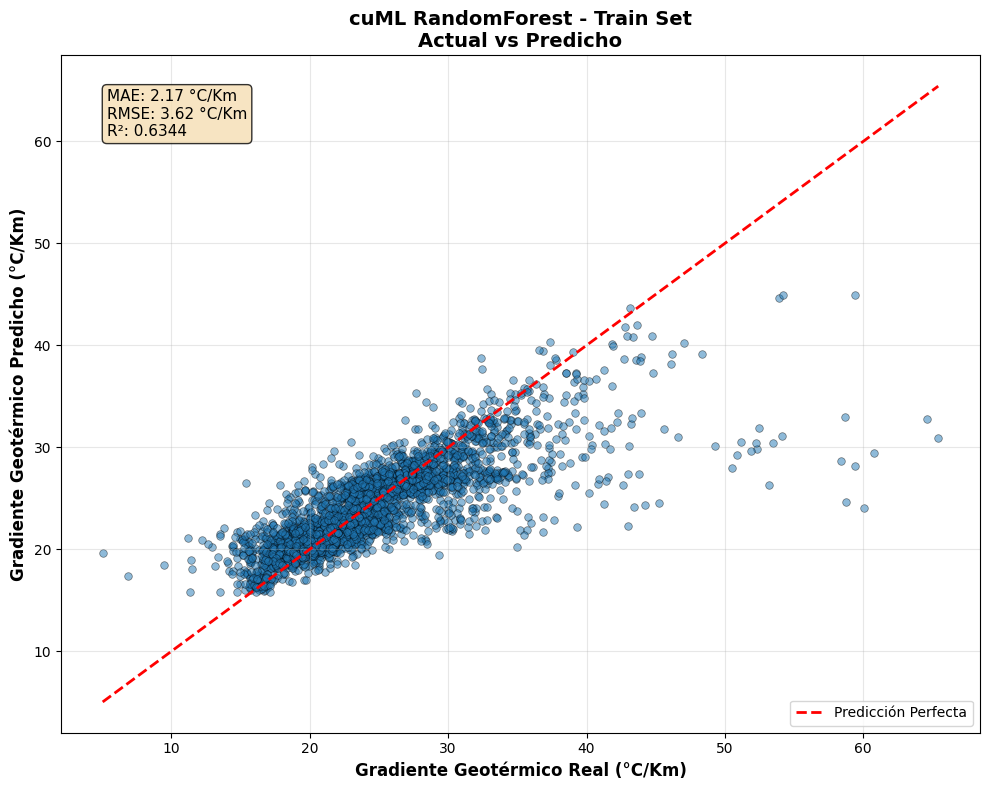

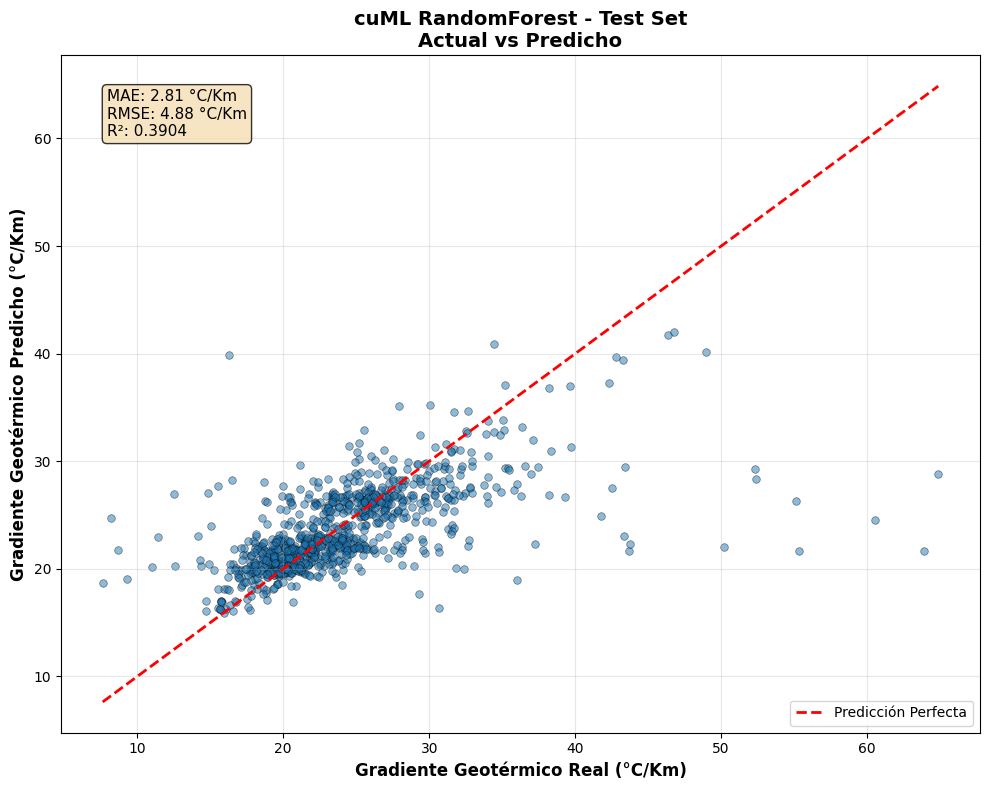

In [76]:
# ==========================================
# FUNCIONES PARA VISUALIZACIÓN
# ==========================================

def plot_actual_vs_predicted(y_actual, y_pred, model_name, dataset_type, save_path):
    """
    Genera gráfica de valores actuales vs predichos

    Args:
        y_actual: Valores reales
        y_pred: Valores predichos
        model_name: Nombre del modelo
        dataset_type: 'Train' o 'Test'
        save_path: Ruta donde guardar la figura
    """
    # Calcular métricas
    mae = mean_absolute_error(y_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    r2 = r2_score(y_actual, y_pred)

    # Crear figura
    plt.figure(figsize=(10, 8))

    # Scatter plot
    plt.scatter(y_actual, y_pred, alpha=0.5, s=30, edgecolors='k', linewidth=0.5)

    # Línea de identidad (predicción perfecta)
    min_val = min(y_actual.min(), y_pred.min())
    max_val = max(y_actual.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Predicción Perfecta')

    # Etiquetas y título
    plt.xlabel('Gradiente Geotérmico Real (°C/Km)', fontsize=12, fontweight='bold')
    plt.ylabel('Gradiente Geotérmico Predicho (°C/Km)', fontsize=12, fontweight='bold')
    plt.title(f'{model_name} - {dataset_type} Set\nActual vs Predicho', fontsize=14, fontweight='bold')

    # Agregar métricas en el gráfico
    textstr = f'MAE: {mae:.2f} °C/Km\nRMSE: {rmse:.2f} °C/Km\nR²: {r2:.4f}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes,
             fontsize=11, verticalalignment='top', bbox=props)

    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Guardar figura
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    return mae, rmse, r2


# ==========================================
# APLICAR A CADA MODELO
# ==========================================

# -----CatBoost--------
# Training Set
mae_catb_train, rmse_catb_train, r2_catb_train = plot_actual_vs_predicted(
    y_train_original_scale,
    y_catb_train_pred_original_scale,
    'CatBoost',
    'Train',
    OUT_DIR / 'catboost_train_plot.png'
)
# Test Set
mae_catb_test, rmse_catb_test, r2_catb_test = plot_actual_vs_predicted(
  y_test_original_scale,
  y_catb_test_pred_original_scale,
  'CatBoost',
  'Test',
  OUT_DIR/ 'catboost_test_plot.png'
)


# --- XGBOOST ---
# Training Set
mae_xgb_train, rmse_xgb_train, r2_xgb_train = plot_actual_vs_predicted(
    y_train_original_scale,
    y_xgb_train_pred_original_scale,
    'XGBoost',
    'Train',
    OUT_DIR / 'xgboost_train_plot.png'
)

# Test Set
mae_xgb_test, rmse_xgb_test, r2_xgb_test = plot_actual_vs_predicted(
    y_test_original_scale,
    y_xgb_test_pred_original_scale,
    'XGBoost',
    'Test',
    OUT_DIR / 'xgboost_test_plot.png'
)

# --- LIGHTGBM ---
# Training Set
mae_lgb_train, rmse_lgb_train, r2_lgb_train = plot_actual_vs_predicted(
    y_train_original_scale,
    y_lgb_train_pred_original_scale,
    'LightGBM',
    'Train',
    OUT_DIR / 'lightgbm_train_plot.png'
)

# Test Set
mae_lgb_test, rmse_lgb_test, r2_lgb_test = plot_actual_vs_predicted(
    y_test_original_scale,
    y_lgb_test_pred_original_scale,
    'LightGBM',
    'Test',
    OUT_DIR / 'lightgbm_test_plot.png'
)


# --- CUML RANDOM FOREST ---
# Training Set
mae_cuml_rf_train, rmse_cuml_rf_train, r2_cuml_rf_train = plot_actual_vs_predicted(
    y_train_original_scale,
    y_cuml_rf_train_pred_original_scale,
    'cuML RandomForest',
    'Train',
    OUT_DIR / 'cuml_rf_train_plot.png'
)

# Test Set
mae_cuml_rf_test, rmse_cuml_rf_test, r2_cuml_rf_test = plot_actual_vs_predicted(
    y_test_original_scale,
    y_cuml_rf_test_pred_original_scale,
    'cuML RandomForest',
    'Test',
    OUT_DIR / 'cuml_rf_test_plot.png'
)


In [74]:
# ==========================================
# TABLA RESUMEN — MÉTRICAS NORMALIZADAS
# ==========================================

from sklearn.metrics import mean_squared_error
rmse_train_catb = np.sqrt(mean_squared_error(y_train_train, y_train_pred))

df_norm = pd.DataFrame({
    'Modelo':      ['CatBoost', 'XGBoost', 'LightGBM', 'cuML RandomForest'],
    # --- Train ---
    'MAE Train':   [mae_train_catb,    mae_train_xgb,    mae_train_lgb,    mae_train_cuml_rf],
    'RMSE Train':  [rmse_train_catb,   rmse_train_xgb,   rmse_train_lgb,   rmse_train_cuml_rf],
    'R² Train':    [r2_train_catb,     r2_train_xgb,     r2_train_lgb,     r2_train_cuml_rf],
    # --- Test ---
    'MAE Test':    [mae_test_catb,     mae_test_xgb,     mae_test_lgb,     mae_test_cuml_rf],
    'RMSE Test':   [rmse_test_catb,    rmse_test_xgb,    rmse_test_lgb,    rmse_test_cuml_rf],
    'R² Test':     [r2_test_catb,      r2_test_xgb,      r2_test_lgb,      r2_test_cuml_rf],
}).set_index('Modelo')

print("=" * 70)
print("        MÉTRICAS NORMALIZADAS (espacio Z-score sobre log1p)")
print("=" * 70)
display(df_norm.style
    .format("{:.6f}")
    .highlight_min(subset=['MAE Train', 'RMSE Train', 'MAE Test', 'RMSE Test'], color='lightgreen')
    .highlight_max(subset=['R² Train', 'R² Test'], color='lightgreen')
    .set_caption("↓ Menor es mejor para MAE/RMSE   |   ↑ Mayor es mejor para R²")
)

        MÉTRICAS NORMALIZADAS (espacio Z-score sobre log1p)


,MAE Train,RMSE Train,R² Train,MAE Test,RMSE Test,R² Test
Modelo,,,,,,
CatBoost,0.419290,0.605699,0.633128,0.498819,0.776138,0.443067
XGBoost,0.380992,0.562948,0.683090,0.497179,0.782732,0.433562
LightGBM,0.401633,0.589081,0.652984,0.500265,0.785595,0.429411
cuML RandomForest,0.381995,0.571599,0.673275,0.497336,0.783564,0.432357


In [75]:
# ==========================================
# TABLA RESUMEN — MÉTRICAS DESNORMALIZADAS
# ==========================================

df_denorm = pd.DataFrame({
    'Modelo':             ['CatBoost', 'XGBoost', 'LightGBM', 'cuML RandomForest'],
    # --- Train ---
    'MAE Train':          [mae_catb_train_denormalized,    mae_xgb_train_denormalized,    mae_lgb_train_denormalized,    mae_cuml_rf_train_denormalized],
    'RMSE Train':         [rmse_catb_train_denormalized,   rmse_xgb_train_denormalized,   rmse_lgb_train_denormalized,   rmse_cuml_rf_train_denormalized],
    'R² Train':           [r2_catb_train_denormalized,     r2_xgb_train_denormalized,     r2_lgb_train_denormalized,     r2_cuml_rf_train_denormalized],
    # --- Test ---
    'MAE Test':           [mae_catb_denormalized,          mae_xgb_denormalized,          mae_lgb_denormalized,          mae_cuml_rf_denormalized],
    'RMSE Test':          [rmse_catb_denormalized,         rmse_xgb_denormalized,         rmse_lgb_denormalized,         rmse_cuml_rf_denormalized],
    'R² Test':            [r2_catb_denormalized,           r2_xgb_denormalized,           r2_lgb_denormalized,           r2_cuml_rf_denormalized],
}).set_index('Modelo')

print("=" * 70)
print("        MÉTRICAS DESNORMALIZADAS (escala original del target)")
print("=" * 70)
display(df_denorm.style
    .format("{:.4f}")
    .highlight_min(subset=['MAE Train', 'RMSE Train', 'MAE Test', 'RMSE Test'], color='lightgreen')
    .highlight_max(subset=['R² Train', 'R² Test'], color='lightgreen')
    .set_caption("↓ Menor es mejor para MAE/RMSE   |   ↑ Mayor es mejor para R²")
)

        MÉTRICAS DESNORMALIZADAS (escala original del target)


,MAE Train,RMSE Train,R² Train,MAE Test,RMSE Test,R² Test
Modelo,,,,,,
CatBoost,2.3670,3.7685,0.6032,2.8194,4.8312,0.4018
XGBoost,2.1614,3.5472,0.6485,2.8092,4.8679,0.3927
LightGBM,2.2747,3.6814,0.6214,2.8265,4.8844,0.3886
cuML RandomForest,2.1709,3.6177,0.6344,2.8126,4.8774,0.3904
